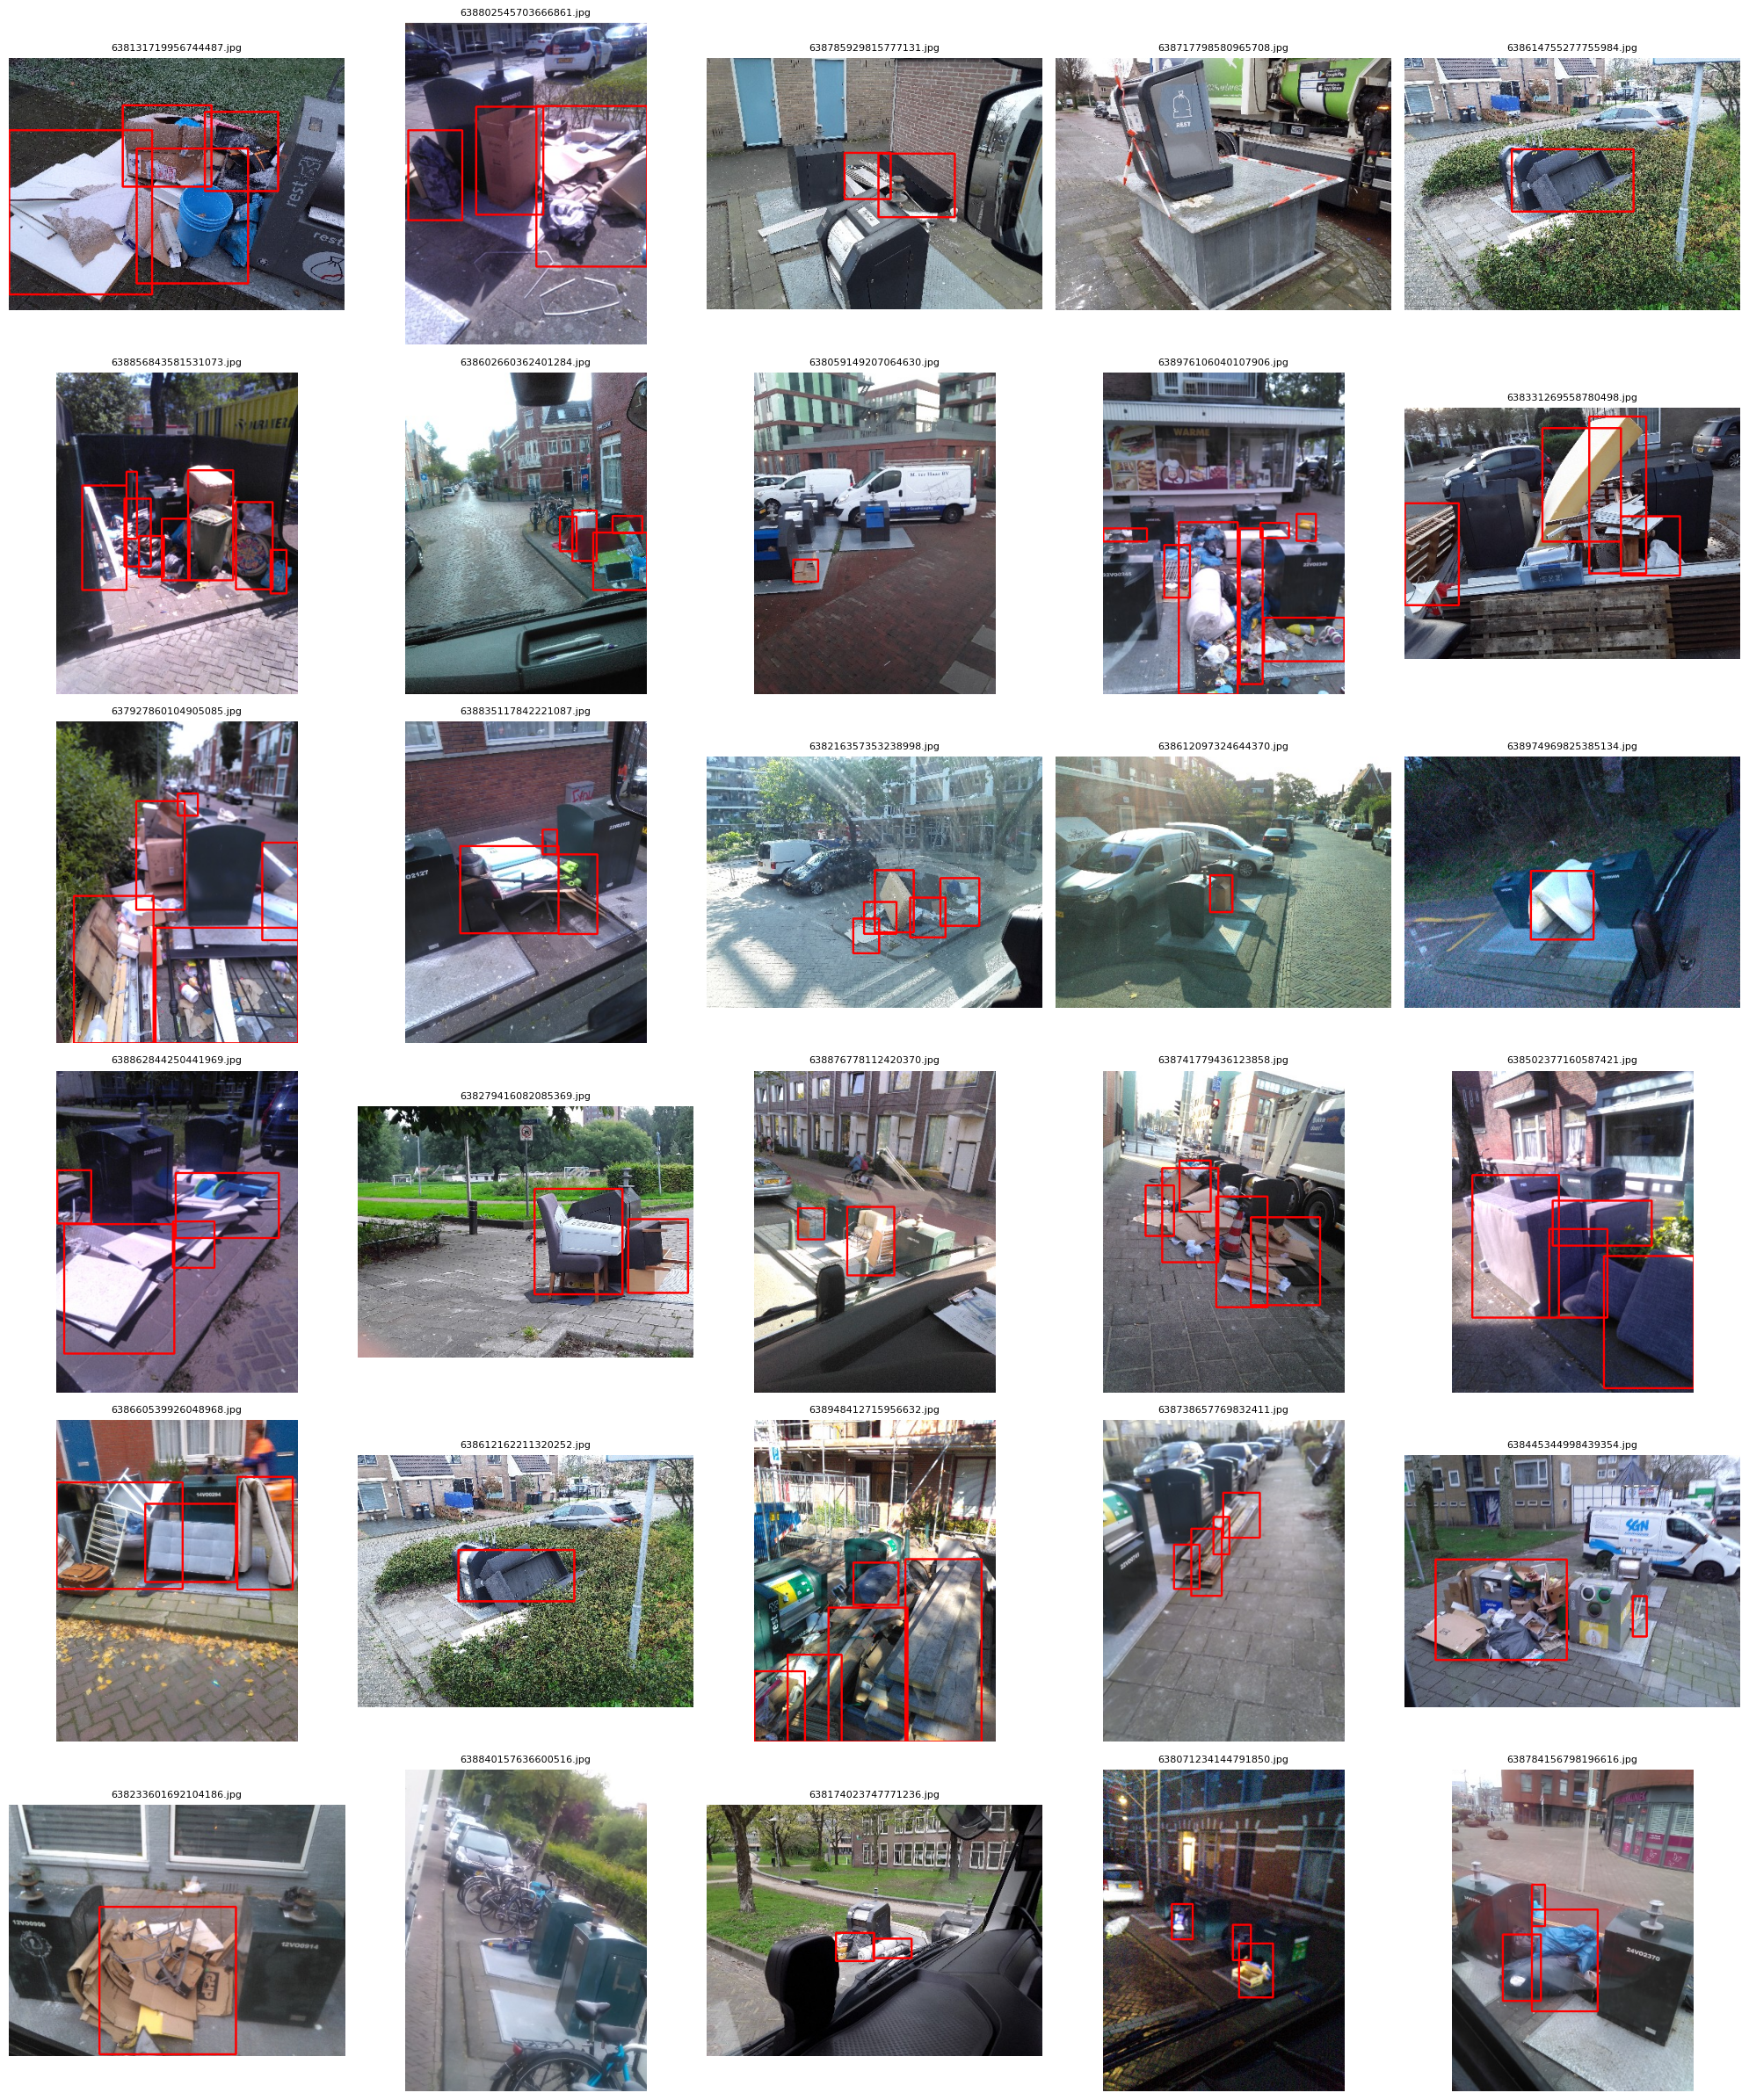

aantal foto's gelabeld in totaal:  473
aantal bboxxes gelabeld in totaal:  1612


In [6]:
import json
import random
import cv2
import matplotlib.pyplot as plt

# Pad naar JSON
json_path = "../annotations_manual_from_notebook.json"

# JSON laden
with open(json_path, "r") as f:
    annotations = json.load(f)

# Kies 30 random afbeeldingen
all_images = list(annotations.keys())
sample_images = random.sample(all_images, min(30, len(all_images)))

# Grid instellingen
cols = 5
rows = 6
fig, axes = plt.subplots(rows, cols, figsize=(20, 24))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_images):
    img = cv2.imread("../" + img_path)
    if img is None:
        ax.axis('off')
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Teken bboxes
    for ann in annotations[img_path]:
        x, y, w, h = ann["bbox"]
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)  # rood
    
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_path.split("/")[-1], fontsize=8)

# Verwijder eventuele lege subplots
for ax in axes[len(sample_images):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

print("aantal foto's gelabeld in totaal: ", len(annotations))
print("aantal bboxxes gelabeld in totaal: ", sum(len(v) for v in annotations.values()))